In [2]:
# CELL 1 — Imports

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import os

print("✅ All imports done")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

✅ All imports done
PyTorch version: 2.5.1+cu121
GPU available: True


In [3]:
# CELL 2 — PATHS (based on your actual folder)

from pathlib import Path

# Repo root: walk up from the notebook's directory until app.py is found.
BASE_PATH    = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "app.py").is_file())
KAGGLE_TRAIN = BASE_PATH / "datasets" / "KAGGLE DATASET" / "Combined Dataset" / "train"
MODELS_PATH  = BASE_PATH / "models"
RESULTS_PATH = BASE_PATH / "results"

# Create folders if they don't exist
os.makedirs(MODELS_PATH,  exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

# Verify paths exist
print("Checking paths:")
for name, path in [("Train data", KAGGLE_TRAIN),
                   ("Models",     MODELS_PATH),
                   ("Results",    RESULTS_PATH)]:
    status = "✅" if os.path.exists(path) else "❌ NOT FOUND"
    print(f"  {status} {name}: {path}")

Checking paths:
  ✅ Train data: datasets\KAGGLE DATASET\Combined Dataset\train
  ✅ Models: models
  ✅ Results: results


In [4]:
# CELL 3 — Load and split data

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = datasets.ImageFolder(
    root=KAGGLE_TRAIN,
    transform=train_transform
)

# Print what was found
print(f"Classes found: {full_dataset.classes}")
print(f"Total images:  {len(full_dataset)}")

# Split 70/15/15
total      = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_data, val_data, test_data = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Create loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

print(f"\nTrain: {train_size} images")
print(f"Val:   {val_size} images")
print(f"Test:  {test_size} images")
print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Classes found: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
Total images:  10240

Train: 7168 images
Val:   1536 images
Test:  1536 images

Train batches: 224
Val batches:   48
Test batches:  48


In [5]:
# CELL 4 — Build VGG16

device = torch.device('cuda' if torch.cuda.is_available() 
                       else 'cpu')
print(f"Using: {device}")

def build_vgg16():
    model = models.vgg16(weights='IMAGENET1K_V1')
    
    # Freeze conv layers
    for param in model.features.parameters():
        param.requires_grad = False
    
    # Replace final classifier layer
    model.classifier[6] = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(4096, 4)
    )
    return model

vgg_model = build_vgg16()

total     = sum(p.numel() for p in vgg_model.parameters())
trainable = sum(p.numel() for p in vgg_model.parameters() 
                if p.requires_grad)

print(f"\n✅ VGG16 built")
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")
print(f"Output classes:   4")
print(f"Classes: {full_dataset.classes}")

Using: cuda

✅ VGG16 built
Total params:     134,276,932
Trainable params: 119,562,244
Output classes:   4
Classes: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']


In [6]:
# CELL 5 — Training function with save

def train_and_save(model, model_name, epochs=20):
    
    model = model.to(device)
    
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.001
    )
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=7, gamma=0.1
    )
    
    best_val_acc  = 0
    train_accs    = []
    val_accs      = []
    
    print(f"Training {model_name} for {epochs} epochs...")
    print("=" * 55)
    
    for epoch in range(epochs):
        
        # ── TRAIN ──────────────────────
        model.train()
        correct = 0
        total   = 0
        
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)
        
        train_acc = 100 * correct / total
        
        # ── VALIDATE ───────────────────
        model.eval()
        correct = 0
        total   = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images  = images.to(device)
                labels  = labels.to(device)
                outputs = model(images)
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item()
                total   += labels.size(0)
        
        val_acc = 100 * correct / total
        scheduler.step()
        
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        # ── SAVE BEST ──────────────────
        saved = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_path    = os.path.join(MODELS_PATH, 
                                        f'{model_name}_best.pth')
            torch.save(model.state_dict(), save_path)
            saved = " ← SAVED ✅"
        
        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train: {train_acc:.1f}% | "
              f"Val: {val_acc:.1f}%{saved}")
    
    print("=" * 55)
    print(f"Best Val Accuracy: {best_val_acc:.2f}%")
    print(f"Saved to: {MODELS_PATH}\\{model_name}_best.pth")
    
    return model, train_accs, val_accs, best_val_acc

print("✅ Training function ready")

✅ Training function ready


In [7]:
# CELL 6 — START TRAINING VGG16

vgg_model, train_accs, val_accs, best_acc = train_and_save(
    model=build_vgg16(),
    model_name='vgg16',
    epochs=20
)

print(f"\n✅ VGG16 COMPLETE")
print(f"Best accuracy: {best_acc:.2f}%")

Training vgg16 for 20 epochs...
Epoch 01/20 | Train: 45.8% | Val: 69.5% ← SAVED ✅
Epoch 02/20 | Train: 55.4% | Val: 68.2%
Epoch 03/20 | Train: 55.1% | Val: 64.1%
Epoch 04/20 | Train: 58.0% | Val: 69.5%
Epoch 05/20 | Train: 59.4% | Val: 73.8% ← SAVED ✅
Epoch 06/20 | Train: 59.3% | Val: 67.6%
Epoch 07/20 | Train: 59.5% | Val: 68.2%
Epoch 08/20 | Train: 62.6% | Val: 75.6% ← SAVED ✅
Epoch 09/20 | Train: 64.5% | Val: 75.4%
Epoch 10/20 | Train: 66.5% | Val: 78.5% ← SAVED ✅
Epoch 11/20 | Train: 66.9% | Val: 76.7%
Epoch 12/20 | Train: 67.6% | Val: 77.1%
Epoch 13/20 | Train: 69.0% | Val: 77.9%
Epoch 14/20 | Train: 69.0% | Val: 79.0% ← SAVED ✅
Epoch 15/20 | Train: 69.6% | Val: 78.6%
Epoch 16/20 | Train: 70.4% | Val: 79.2% ← SAVED ✅
Epoch 17/20 | Train: 70.3% | Val: 77.7%
Epoch 18/20 | Train: 71.1% | Val: 77.1%
Epoch 19/20 | Train: 70.6% | Val: 77.9%
Epoch 20/20 | Train: 70.5% | Val: 78.5%
Best Val Accuracy: 79.23%
Saved to: models\vgg16_best.pth

✅ VGG16 COMPLETE
Best accuracy: 79.23%


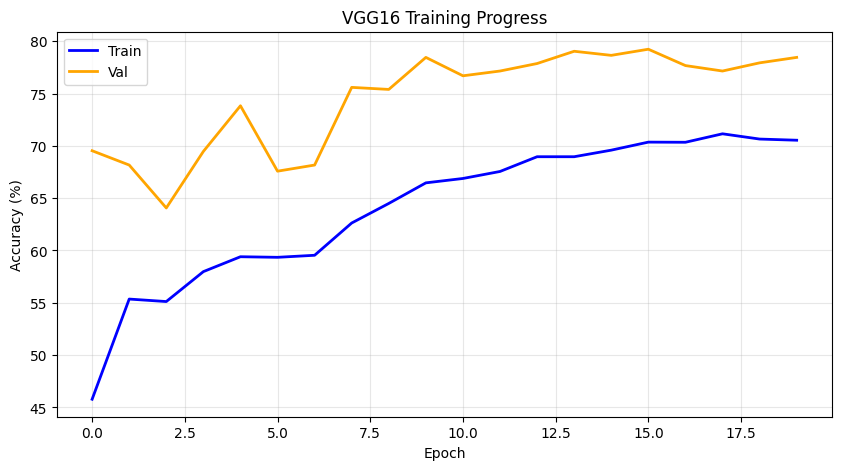

✅ Plot saved

VGG16 FINAL TEST ACCURACY: 75.39%
                      precision    recall  f1-score   support

     Mild Impairment       0.93      0.67      0.78       382
 Moderate Impairment       0.99      0.99      0.99       377
       No Impairment       0.68      0.68      0.68       386
Very Mild Impairment       0.54      0.69      0.60       391

            accuracy                           0.75      1536
           macro avg       0.78      0.76      0.76      1536
        weighted avg       0.78      0.75      0.76      1536



In [8]:
# CELL 7 — Plot training curve + test accuracy

# Plot
plt.figure(figsize=(10, 5))
plt.plot(train_accs, label='Train', color='blue',   linewidth=2)
plt.plot(val_accs,   label='Val',   color='orange', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('VGG16 Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(RESULTS_PATH, 'vgg16_training.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved")

# Test accuracy
vgg_model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = vgg_model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds) * 100
print(f"\n{'='*40}")
print(f"VGG16 FINAL TEST ACCURACY: {test_acc:.2f}%")
print(f"{'='*40}")
print(classification_report(
    all_labels, all_preds,
    target_names=full_dataset.classes
))